# ЛР 5

Посмотрите на данные датчика, который отслеживает атмосферный CO2 из непрерывных проб воздуха в обсерватории Мауна-Лоа на Гавайях. Эти данные включают пробы CO2 с марта 1958 года по декабрь 1980 года.
- Определите наличие основного тренда и сезонности в данных.
- Определите, являются ли данные стационарными.
- Разделите данные на обучающие (90%) и тестовые (10%).
- Найдите набор моделей-кандидатов SARIMAX, посмотрев на ACF и PACF.
- Выполните поиск по сетке для моделей-кандидатов.
- Выберите лучшие модели на основе показателей производительности, сложности модели и нормальности остатков.
- Сравните лучшую найденную вами модель с моделью из autoarima.


Модель SARIMA(p,d,q)(P,D,Q)[s]  
Цель Построить оптимальную модель SARIMAX и сравнить её с AutoARIMA

## Импорты

In [2]:
import sys
print(sys.executable)
!{sys.executable} -m pip install -U tqdm ipywidgets pmdarima

c:\Users\RomanovHome\AppData\Local\Programs\Python\Python311\python.exe



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import warnings
warnings.filterwarnings("ignore")
from statsmodels.tools.sm_exceptions import ConvergenceWarning, ValueWarning
warnings.simplefilter('ignore', ConvergenceWarning)
warnings.simplefilter('ignore', ValueWarning)
warnings.simplefilter('ignore', UserWarning)

import time
from itertools import product
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels as ss
import seaborn as sns
from tqdm.notebook import tqdm
from scipy import stats
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import month_plot, plot_acf, plot_pacf
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.eval_measures import mse
from statsmodels.tsa.statespace.tools import diff
import pmdarima as pm
np.random.seed(0)



## Загрузка данных CO2

In [4]:
co2 = pd.read_csv(
    'https://zenodo.org/records/10951538/files/arima_co2.csv?download=1',
    header=0,
    names=['idx', 'co2'],
    skipfooter=2,
    engine='python'
)
co2['idx'] = pd.to_datetime(co2['idx'])
co2.set_index('idx', inplace=True)
co2.index.name = None

print(f"Размер датасета: {co2.shape}")
print(f"Период: {co2.index[0].strftime('%B %Y')} - {co2.index[-1].strftime('%B %Y')}")
co2.head()

Размер датасета: (192, 1)
Период: January 1965 - December 1980


,co2
1965-01-01,319.32
1965-02-01,320.36
1965-03-01,320.82
1965-04-01,322.06
1965-05-01,322.17


## Шаг 1: Анализ тренда и сезонности

### Исходный ряд и декомпозиция

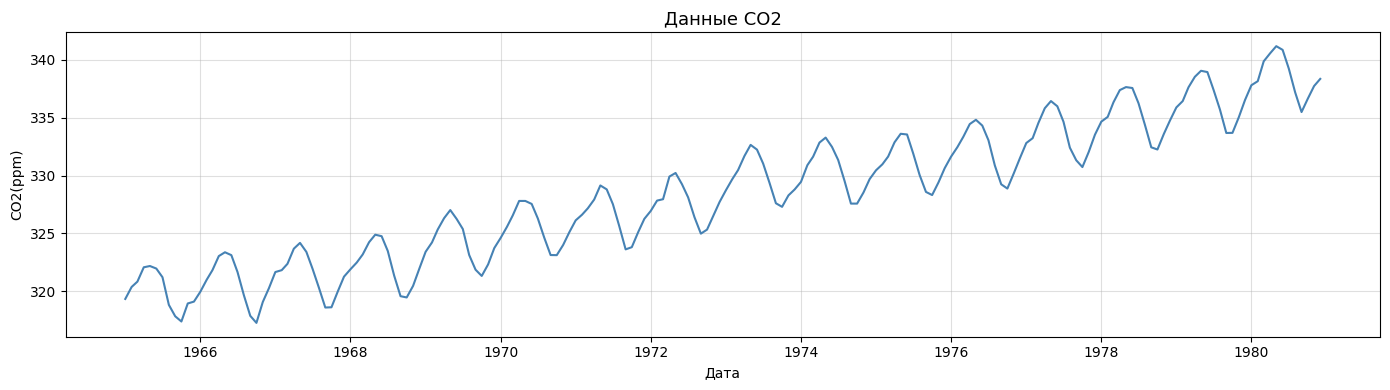

In [5]:
# график исходного ряда
plt.figure(figsize=(14, 4))
plt.plot(co2['co2'], color='steelblue')
plt.title('Данные CO2', fontsize=13)
plt.xlabel('Дата')
plt.ylabel('CO2(ppm)')
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

Декомпозиция (seasonal_decompose)

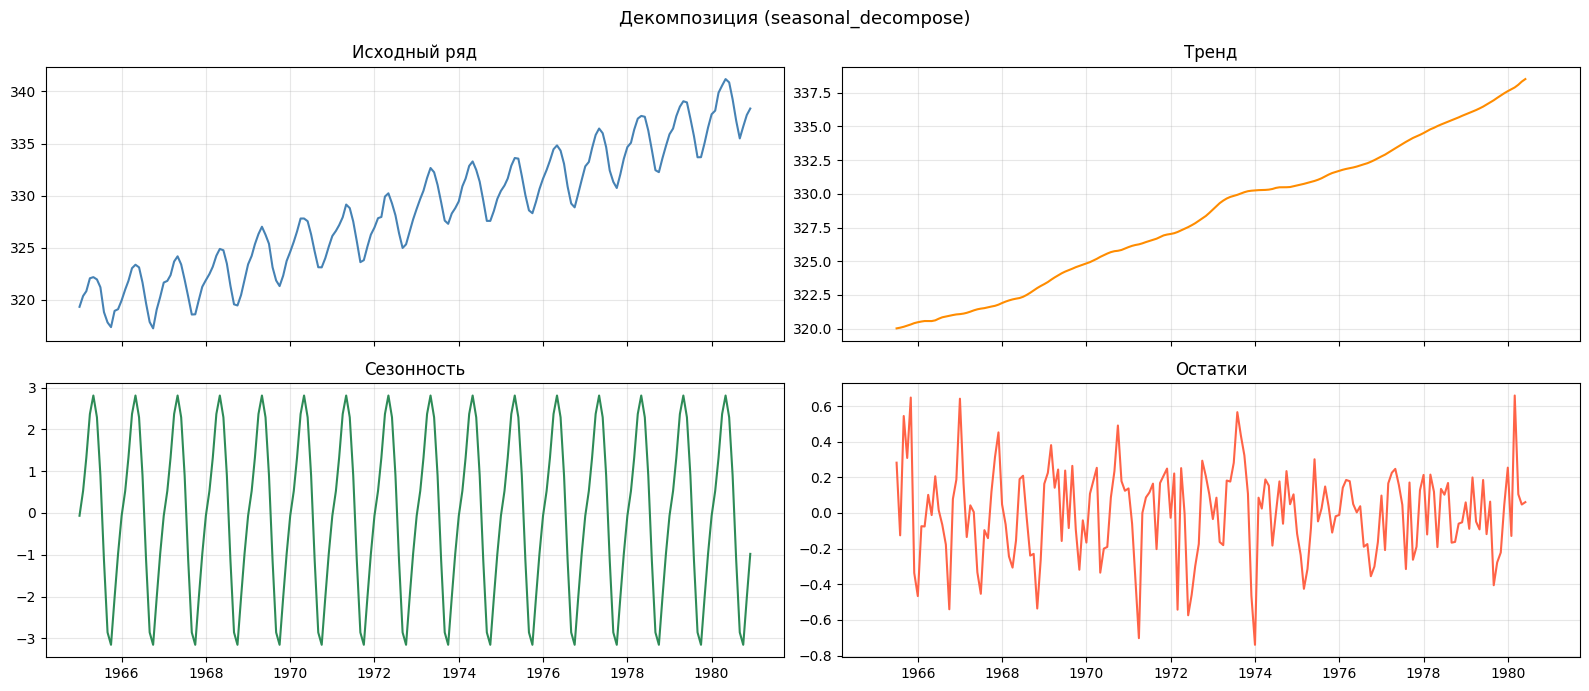

In [6]:
decomp_sd = seasonal_decompose(co2['co2'], model='additive', period=12)

fig, axs = plt.subplots(2, 2, sharex=True, figsize=(16, 7))
fig.suptitle('Декомпозиция (seasonal_decompose)', fontsize=13)
axs[0, 0].plot(co2['co2'], color='steelblue')
axs[0, 0].set_title('Исходный ряд')
axs[0, 1].plot(decomp_sd.trend, color='darkorange')
axs[0, 1].set_title('Тренд')
axs[1, 0].plot(decomp_sd.seasonal, color='seagreen')
axs[1, 0].set_title('Сезонность')
axs[1, 1].plot(decomp_sd.resid, color='tomato')
axs[1, 1].set_title('Остатки')
for ax in axs.flatten():
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Декомпозиция (STL)

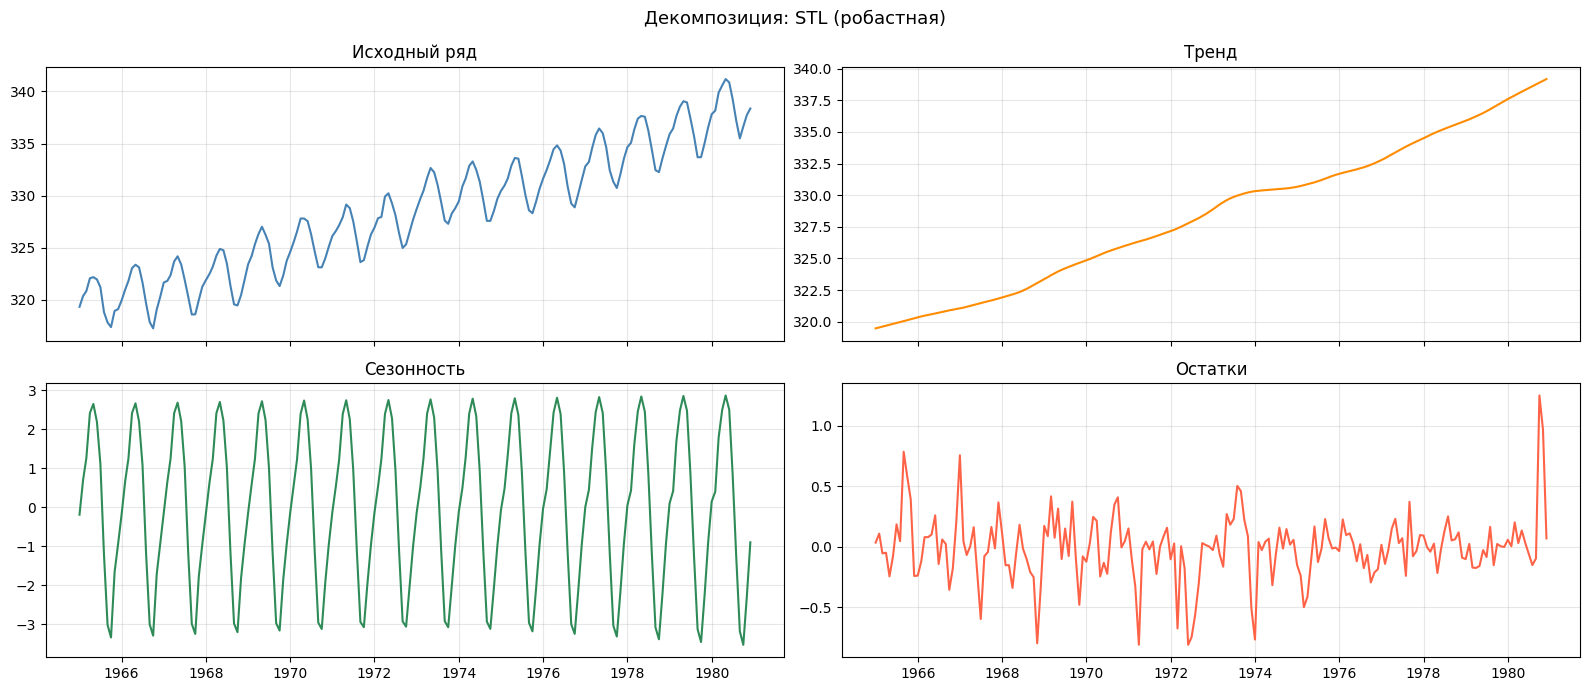

In [7]:
decomp_stl = STL(co2['co2'], period=12, seasonal=13, robust=True).fit()

fig, axs = plt.subplots(2, 2, sharex=True, figsize=(16, 7))
fig.suptitle('Декомпозиция: STL (робастная)', fontsize=13)
axs[0, 0].plot(co2['co2'], color='steelblue')
axs[0, 0].set_title('Исходный ряд')
axs[0, 1].plot(decomp_stl.trend, color='darkorange')
axs[0, 1].set_title('Тренд')
axs[1, 0].plot(decomp_stl.seasonal, color='seagreen')
axs[1, 0].set_title('Сезонность')
axs[1, 1].plot(decomp_stl.resid, color='tomato')
axs[1, 1].set_title('Остатки')
for ax in axs.flatten():
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Оба метода декомпозиции показываают восходящий тренд  на протяжении всего периода . Тренд носит нелинейный характер, темп роста постепенно ускоряется 

Сезонная составляющая чётко выражена. Амплитуда сезонных колебаний остаётся примерно постоянной на протяжении всего ряда

после исключения тренда и сезонности остатки выглядят как близкий к белому шуму (колебания случайны)


## Шаг 2: Проверка стационарности

ADF тесты

=== Исходный ряд ===
  ADFстат: 1.2697
  p-значение: 0.9964
  Крит.знач: 1%: -3.467, 5%: -2.878, 10%: -2.575
  Вывод: Нестационарный (p >= 0.05)



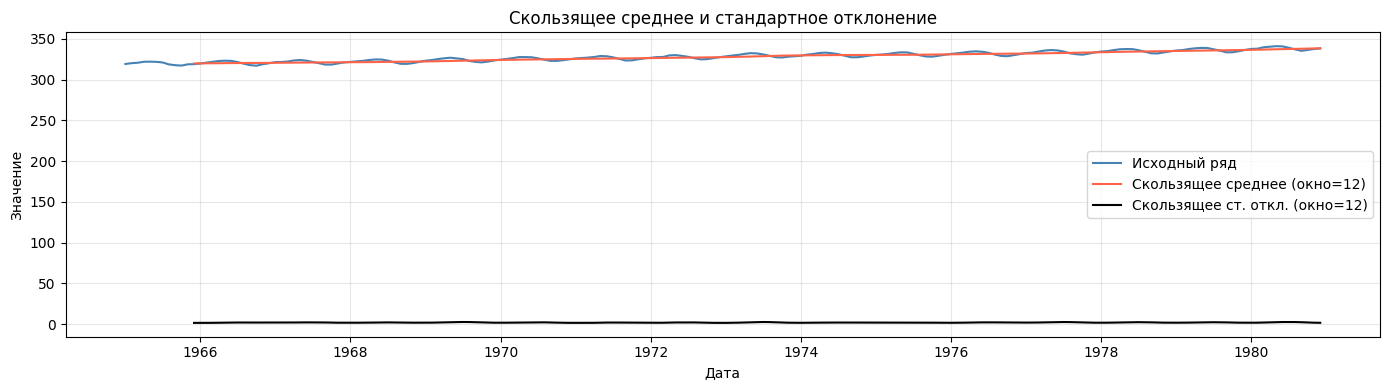

=== После сезонного дифференцирования (D=1) ===
  ADFстат: -2.8202
  p-значение: 0.0554
  Крит.знач: 1%: -3.471, 5%: -2.879, 10%: -2.576
  Вывод: Нестационарный (p >= 0.05)



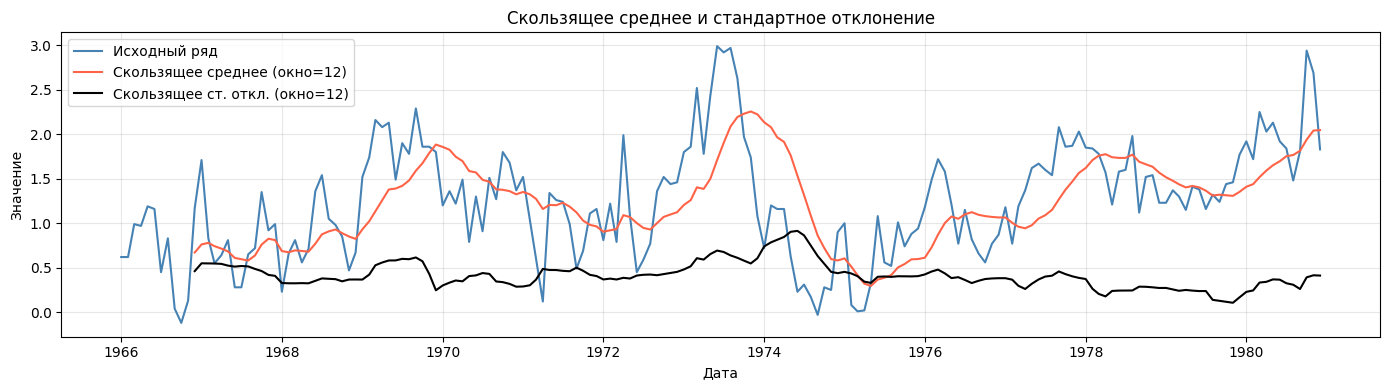

=== После сезонного и обычного дифференцирования (D=1, d=1) ===
  ADFстат: -5.2093
  p-значение: 0.0000
  Крит.знач: 1%: -3.470, 5%: -2.879, 10%: -2.576
  Вывод: Стационарный (p < 0.05)



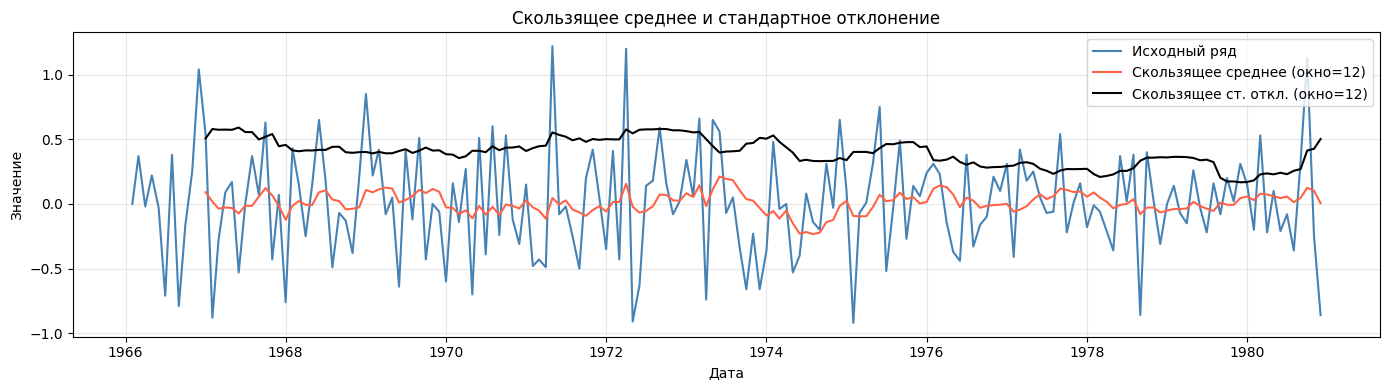

In [8]:
def adftest(series, plots=True):
    out = adfuller(series, autolag='AIC')
    print(f'  ADFстат: {out[0]:.4f}')
    print(f'  p-значение: {out[1]:.4f}')
    crit_vals = ", ".join([f"{k}: {v:.3f}" for k, v in out[4].items()])
    print(f'  Крит.знач: {crit_vals}')
    verdict = "Стационарный (p < 0.05)" if out[1] < 0.05 else "Нестационарный (p >= 0.05)"
    print(f'  Вывод: {verdict}\n')

    if plots:
        rolmean = series.rolling(window=12).mean()
        rolstd  = series.rolling(window=12).std()
        plt.figure(figsize=(14, 4))
        plt.plot(series,  color='steelblue', label='Исходный ряд')
        plt.plot(rolmean, color='tomato',    label='Скользящее среднее (окно=12)')
        plt.plot(rolstd,  color='black',     label='Скользящее ст. откл. (окно=12)')
        plt.title('Скользящее среднее и стандартное отклонение')
        plt.xlabel('Дата'); plt.ylabel('Значение')
        plt.legend(loc='best'); plt.grid(alpha=0.3)
        plt.tight_layout(); plt.show()

print('=== Исходный ряд ===')
adftest(co2['co2'])

print('=== После сезонного дифференцирования (D=1) ===')
adftest(co2['co2'].diff(12).dropna())

print('=== После сезонного и обычного дифференцирования (D=1, d=1) ===')
adftest(co2['co2'].diff(12).diff().dropna())

Как мы уже все поняли прежде чем строить модель SARIMA(ARIMA), ряд должен быть стационарным, то есть его среднее и дисперсия не должны меняться со временем.нестационарность устраняется дифференцированием

Исходный ряд нестационарен из-за устойчивого восходящего тренда (скользящее среднее непрерывно растёт, p ~ 1)  
Одного сезонного дифференцирования оказалось недостаточно, получилось p = 0.0554 > 0.05, ряд формально не прошёл тест. Скользящее среднее ещё нестабильно
Вот двойное дифференцирование устраняет и сезонность, и линейный тренд, ряд стационарен (p < 0.0001), скользящее среднее колеблется около нуля


## Шаг 3: Разделение на обучающую и тестовую выборки

Разделение данных 90%/10%

In [9]:
split_idx = int(len(co2) * 0.9)
train = co2.iloc[:split_idx]
test  = co2.iloc[split_idx:]

print(f"Обучающая выборка: {len(train)} наблюдений  ({train.index[0].strftime('%Y-%m')} - {train.index[-1].strftime('%Y-%m')})")
print(f"Тестовая выборка : {len(test)}  наблюдений  ({test.index[0].strftime('%Y-%m')} - {test.index[-1].strftime('%Y-%m')})")
print(f"Сезонных циклов в тестовой выборке: {len(test) / 12:.1f}")

Обучающая выборка: 172 наблюдений  (1965-01 - 1979-04)
Тестовая выборка : 20  наблюдений  (1979-05 - 1980-12)
Сезонных циклов в тестовой выборке: 1.7


График разделения

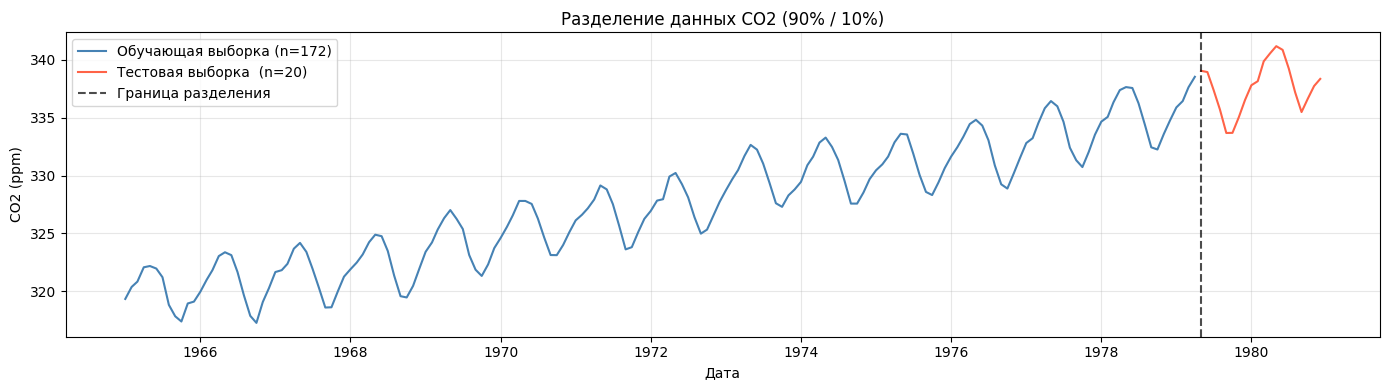

In [10]:
plt.figure(figsize=(14, 4))
plt.plot(train['co2'], label=f'Обучающая выборка (n={len(train)})', color='steelblue')
plt.plot(test['co2'],  label=f'Тестовая выборка  (n={len(test)})',  color='tomato')
plt.axvline(x=test.index[0], color='black', linestyle='--', alpha=0.7, label='Граница разделения')
plt.title('Разделение данных CO2 (90% / 10%)')
plt.xlabel('Дата')
plt.ylabel('CO2 (ppm)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Весь датасет охватывает ~192 наблюдения. Разделение 90/10 даёт ~172 наблюдений в обучающей и ~20 в тестовой выборке
Тестовая выборка ~20 месяцев
 
сделали разделение строго по временной границе, где обучающая выборка содержит только прошлое относительно тестовой

## Шаг 4:Определение параметров-кандидатов через ACF и PACF

Дифференцирование и фильтрация по ADF

In [11]:
def differencing(timeseries, s, D_max=2, d_max=2):
    """Строит DataFrame всех комбинаций сезонного и обычного дифференцирования."""
    ts = timeseries.copy()

    #сезонное дифференцирование от 0 до Dmax
    seas_differenced = []
    for i in range(D_max + 1):
        ts.name = f"d0_D{i}_s{s}"
        seas_differenced.append(ts.copy())
        ts = ts.diff(periods=s)
    seas_df = pd.DataFrame(seas_differenced).T

    #обычное дифференцирование лагом 1 поверх каждого сезонного
    general_differenced = []
    for j, s_ts in enumerate(seas_differenced):
        cur = s_ts.copy()
        for i in range(1, d_max + 1):
            cur = cur.diff()
            cur.name = f"d{i}_D{j}_s{s}"
            general_differenced.append(cur.copy())
    gen_df = pd.DataFrame(general_differenced).T

    return pd.concat([seas_df, gen_df], axis=1)

выполняет тест ADF для всех столбцов и возвращает сводную таблицу

In [12]:
def adf_summary(diff_series):
    summary = []
    for col in diff_series.columns:
        series_clean = diff_series[col].dropna()
        a, b, c, d, e, f = adfuller(series_clean)
        g, h, k = list(e.values())
        summary.append([a, b, c, d, g, h, k])

    columns = ["Тест-статистика", "p-значение", "Лагов", "Наблюдений",
               "Критич.1%", "Критич.5%", "Критич.10%"]
    return pd.DataFrame(summary, index=diff_series.columns, columns=columns)

# Создаём все комбинации дифференцирования на обучающей выборке
diff_series = differencing(train['co2'], s=12, D_max=2, d_max=2)

# Оцениваем стационарность по ADF
summary = adf_summary(diff_series)

# Фильтруем по p < 0.05
summary_passed = summary[summary["p-значение"] < 0.05]
print(f"Прошли тест ADF (p < 0.05): {len(summary_passed)} из {len(summary)} комбинаций\n")
print("Список стационарных кандидатов:")
display(summary_passed[["p-значение", "Тест-статистика"]].round(4))

# Сохраняем прошедшие ряды
index_list = list(summary_passed.index)
passed_series = diff_series[index_list].sort_index(axis=1)

Прошли тест ADF (p < 0.05): 8 из 9 комбинаций

Список стационарных кандидатов:


,p-значение,Тест-статистика
d0_D1_s12,0.0406,-2.9430
d0_D2_s12,0.0099,-3.4318
d1_D0_s12,0.0037,-3.7307
d2_D0_s12,0.0000,-10.4251
d1_D1_s12,0.0000,-5.0470
d2_D1_s12,0.0000,-5.0814
d1_D2_s12,0.0000,-4.8313
d2_D2_s12,0.0001,-4.7923


Значимые выбросы PACF (AR-кандидаты) и ACF (MA-кандидаты)

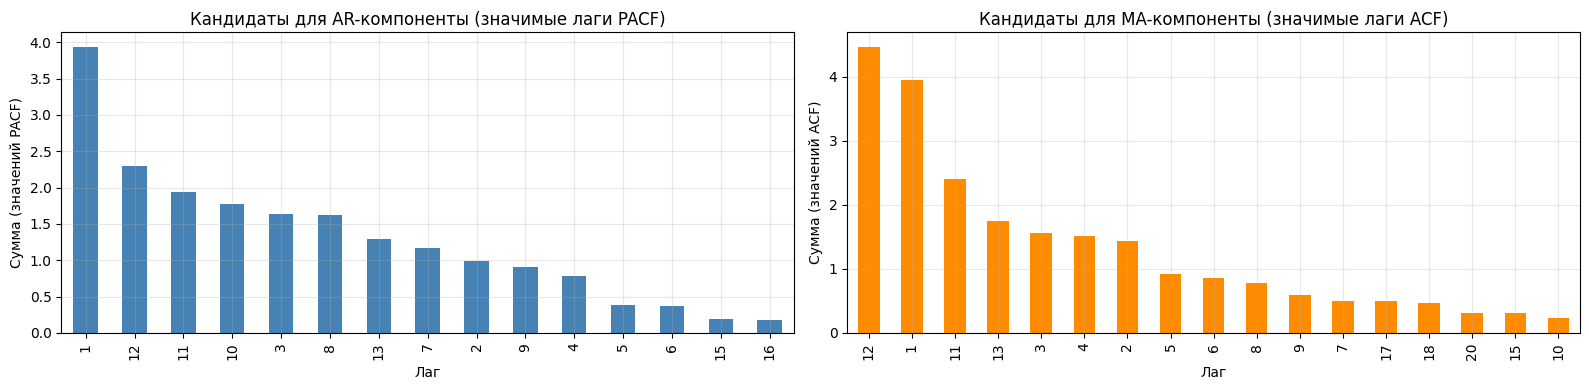

In [21]:
df_sp_p = pd.DataFrame()
for col in passed_series.columns:
    PACF_vals, PACF_ci = pacf(passed_series[col].dropna(), alpha=0.05, method='ywm')
    ci_ll = PACF_ci[:, 0] - PACF_vals
    ci_ul = PACF_ci[:, 1] - PACF_vals
    sp1 = np.where(PACF_vals < ci_ll)[0]
    sp2 = np.where(PACF_vals > ci_ul)[0]
    sp1_vals = pd.Series(np.abs(PACF_vals[PACF_vals < ci_ll]), index=sp1)
    sp2_vals = pd.Series(PACF_vals[PACF_vals > ci_ul], index=sp2)
    df_sp_p = pd.concat([df_sp_p, sp1_vals, sp2_vals], axis=1)

df_sp_p = df_sp_p.sort_index()
pacf_sums = df_sp_p.iloc[1:].T.sum().dropna().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
pacf_sums.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Кандидаты для AR-компоненты (значимые лаги PACF)')
axes[0].set_xlabel('Лаг')
axes[0].set_ylabel('Сумма (значений PACF)')
axes[0].grid(alpha=0.3)

# Аналогично для ACF
df_sp_q = pd.DataFrame()
for col in passed_series.columns:
    ACF_vals, ACF_ci = acf(passed_series[col].dropna(), alpha=0.05)
    ci_ll = ACF_ci[:, 0] - ACF_vals
    ci_ul = ACF_ci[:, 1] - ACF_vals
    sp1 = np.where(ACF_vals < ci_ll)[0]
    sp2 = np.where(ACF_vals > ci_ul)[0]
    sp1_vals = pd.Series(np.abs(ACF_vals[ACF_vals < ci_ll]), index=sp1)
    sp2_vals = pd.Series(ACF_vals[ACF_vals > ci_ul], index=sp2)
    df_sp_q = pd.concat([df_sp_q, sp1_vals, sp2_vals], axis=1)

df_sp_q = df_sp_q.sort_index()
acf_sums = df_sp_q.iloc[1:].T.sum().dropna().sort_values(ascending=False)

acf_sums.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Кандидаты для MA-компоненты (значимые лаги ACF)')
axes[1].set_xlabel('Лаг')
axes[1].set_ylabel('Сумма (значений ACF)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Из всех комбинаций дифференцирования тест ADF прошли только те, где применялось сезонное дифференцирование D=1 (во 2 шаге у первое дифференциирование не давало идеально нужного результата)

На PACF заметны значимые выбросы на лагах 1 и 2, значит для AR-части берём p = 0, 1 или 2. На ACF выбросы тоже на первых двух лагах, поэтому для MAчасти q = 0, 1 или 2. На 12-м лаге (сезонном) в обоих графиках есть пики, поэтому сезонные составляющие ограничиваем P = 0 или 1 и Q = 0 или 1. D фиксируем на 1, s = 12

перебираем 72 комбинации: p(3) * d(2) * q(3) * P(2) * D(1) * Q(2)


## Шаг 5: Поиск по сетке

Перебираем комбинации SARIMA и возвращаем DataFrame метрик качества

In [23]:
warnings.simplefilter("ignore")

def SARIMA_grid(endog, order, seasonal_order):
    model_info = []
    for i in tqdm(order, desc='pdq'):
        for j in seasonal_order:
            try:
                model_fit = SARIMAX(endog=endog, order=i, seasonal_order=j).fit(disp=False)
                predict = model_fit.predict()
                endog_vals = endog.values if hasattr(endog, 'values') else endog
                pred_vals  = predict.values if hasattr(predict, 'values') else predict
                MAPE = float(np.abs((endog_vals[1:] - pred_vals[1:]) / endog_vals[1:]).mean())
                MSE_val = float(mse(endog_vals[1:], pred_vals[1:]))
                AIC = model_fit.aic
                BIC = model_fit.bic
                model_info.append([i, j, MAPE, MSE_val, AIC, BIC])
            except Exception:
                continue

    columns = ['порядок', 'сезонный_порядок', 'MAPE', 'MSE', 'AIC', 'BIC']
    return pd.DataFrame(data=model_info, columns=columns)


# сетка параметров (берем из анализа ACF/PACF и здравого смысла)))
p_vals = [0, 1, 2]
d_vals = [0, 1]
q_vals = [0, 1, 2]
P_vals = [0, 1]
D_vals = [1]
Q_vals = [0, 1]
s_val  = [12]

pdq   = list(product(p_vals, d_vals, q_vals))
PDQs  = list(product(P_vals, D_vals, Q_vals, s_val))

print(f"Всего комбинаций: {len(pdq)} * {len(PDQs)} = {len(pdq) * len(PDQs)}")

start_time = time.time()
model_info = SARIMA_grid(endog=train['co2'], order=pdq, seasonal_order=PDQs)
elapsed = time.time() - start_time

print(f"\nУспешно подобрано: {len(model_info)} из {len(pdq) * len(PDQs)}")
print(f"Время выполнения: {elapsed:.1f} сек ({elapsed/60:.1f} мин)")

print("\n10 лучших моделей по AIC:")
display(model_info.nsmallest(10, 'AIC').reset_index(drop=True))

Всего комбинаций: 18 * 4 = 72


pdq:   0%|          | 0/18 [00:00<?, ?it/s]


Успешно подобрано: 72 из 72
Время выполнения: 17.6 сек (0.3 мин)

10 лучших моделей по AIC:


,порядок,сезонный_порядок,MAPE,MSE,AIC,BIC
0,"(0, 1, 1)","(0, 1, 1, 12)",0.003812,147.662391,90.471897,99.678610
1,"(1, 1, 1)","(0, 1, 1, 12)",0.003808,147.660731,91.094462,103.370078
2,"(1, 1, 0)","(0, 1, 1, 12)",0.003810,147.663006,91.393238,100.599951
3,"(2, 1, 1)","(0, 1, 1, 12)",0.003806,147.660250,91.827053,107.171574
4,"(0, 1, 2)","(0, 1, 1, 12)",0.003812,147.661996,92.156539,104.432156
5,"(0, 1, 1)","(1, 1, 1, 12)",0.003811,147.662519,92.317650,104.593267
6,"(1, 1, 2)","(0, 1, 1, 12)",0.003807,147.660442,92.318677,107.663198
7,"(2, 1, 2)","(0, 1, 1, 12)",0.003804,147.659566,93.053970,111.467395
8,"(1, 1, 1)","(1, 1, 1, 12)",0.003808,147.660782,93.086994,108.431515
9,"(1, 1, 0)","(1, 1, 1, 12)",0.003809,147.663162,93.199356,105.474973


все 72 модели сошлись без ошибок, перебор занял около 18 секунд

лучшая по AIC это SARIMA(0,1,1)(0,1,1,12), AIC=90.47. разрыв с 2м местом небольшой (где-то 0.6), так что несколько моделей конкурентоспособны. но видно, что все топовые модели сходятся на Q=1 в сезонной части. это подтверждает то, что мы видели на ACF

## Шаг 6:Выбор модели и анализ остатков

Лучшие модели по каждому критерию и прогнозы

,порядок,сезонный_порядок,MAPE,MSE,AIC,BIC
0,"(2, 1, 2)","(1, 1, 1, 12)",0.003804,147.659640,95.019603,116.501932
1,"(2, 1, 2)","(0, 1, 1, 12)",0.003804,147.659566,93.053970,111.467395
2,"(0, 1, 1)","(0, 1, 1, 12)",0.003812,147.662391,90.471897,99.678610


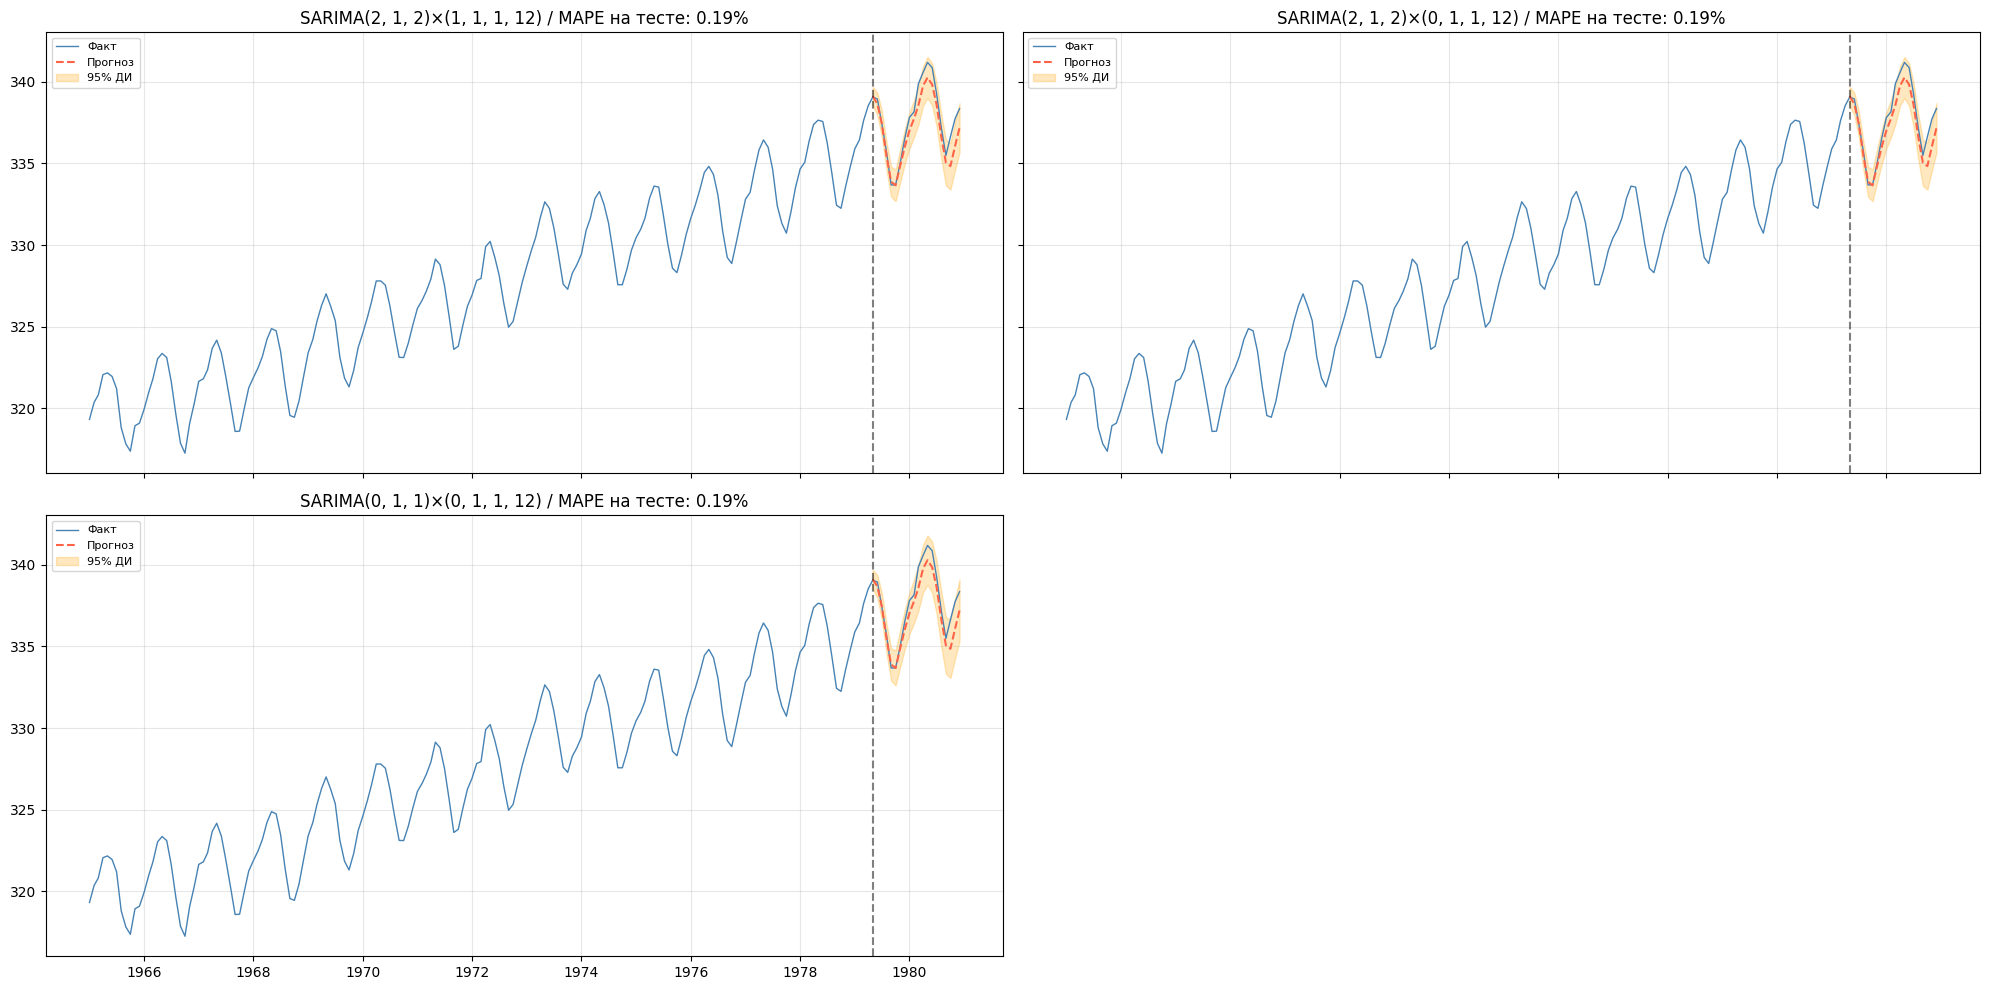

In [25]:
# Лучшие по каждому критерию
L1 = model_info[model_info['MAPE'] == model_info['MAPE'].min()].head(1)
L2 = model_info[model_info['MSE']  == model_info['MSE'].min()].head(1)
L3 = model_info[model_info['AIC']  == model_info['AIC'].min()].head(1)
L4 = model_info[model_info['BIC']  == model_info['BIC'].min()].head(1)

best_models = pd.concat([L1, L2, L3, L4]).drop_duplicates(subset=['порядок', 'сезонный_порядок'])
best_models = best_models.reset_index(drop=True)

display(best_models)

# Подбор моделей и прогнозы
n_models = len(best_models)
preds, ci_low, ci_up, mape_test_list = [], [], [], []
criteria_names = ['MAPE', 'MSE', 'AIC', 'BIC'][:n_models]

for i in range(n_models):
    ord_i  = tuple(best_models.iloc[i]['порядок'])
    sord_i = tuple(best_models.iloc[i]['сезонный_порядок'])
    fit = SARIMAX(endog=train['co2'], order=ord_i, seasonal_order=sord_i).fit(disp=False)
    pred_summary = fit.get_prediction(test.index[0], test.index[-1]).summary_frame()
    preds.append(pred_summary['mean'])
    ci_low.append(pred_summary['mean_ci_lower'])
    ci_up.append(pred_summary['mean_ci_upper'])
    mape_val = float(np.abs((test['co2'].values - pred_summary['mean'].values) / test['co2'].values).mean())
    mape_test_list.append(mape_val)

# Визуализация 2×2
nrows = (n_models + 1) // 2
fig, axs = plt.subplots(nrows, 2, figsize=(20, 5 * nrows), sharex=True, sharey=True)
axs = np.array(axs).flatten()

for k in range(n_models):
    ax = axs[k]
    ord_k  = tuple(best_models.iloc[k]['порядок'])
    sord_k = tuple(best_models.iloc[k]['сезонный_порядок'])
    ax.plot(co2['co2'], label='Факт', color='steelblue', linewidth=1)
    ax.plot(preds[k],   label='Прогноз', color='tomato', linestyle='--', linewidth=1.5)
    ax.fill_between(test.index, ci_low[k], ci_up[k], color='orange', alpha=0.25, label='95% ДИ')
    ax.axvline(test.index[0], color='black', linestyle='--', alpha=0.5)
    ax.set_title(f'SARIMA{ord_k}×{sord_k} / MAPE на тесте: {mape_test_list[k]:.2%}')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Скрываем лишние оси
for k in range(n_models, len(axs)):
    axs[k].set_visible(False)

plt.tight_layout()
plt.show()

Диагностика остатков лучшей модели по AIC

Лучшая модель по AIC: SARIMA(0, 1, 1)*(0, 1, 1, 12)
AIC = 90.47  /  BIC = 99.68
MAPE (train) = 0.0038



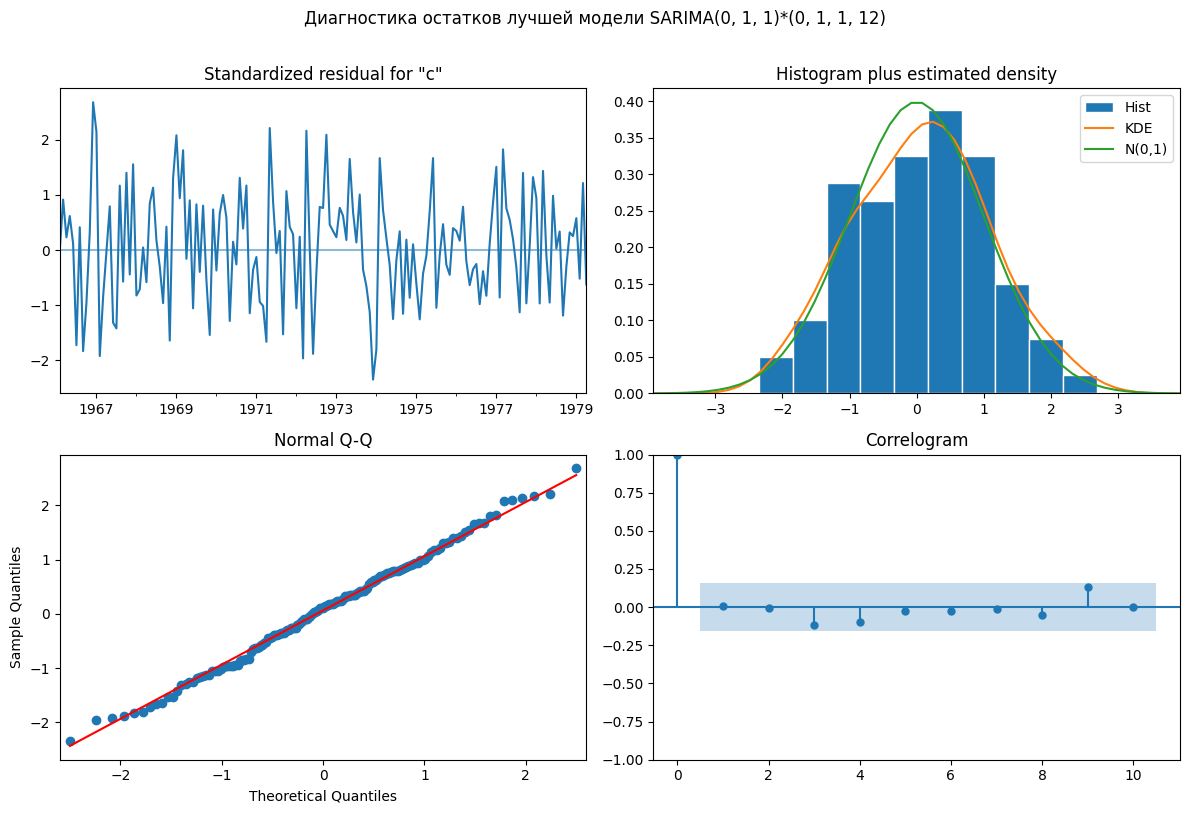


Сводная таблица диагностики остатков:


,Тест,p-значение,Ho не отвергается
0,Жак-Бера (нормальность),0.6088,ok
1,Шапиро-Уилк (нормальность),0.0000,bad
2,Льюнг-Бокс (автокорр.),0.6933,ok
3,Гетероскедастичность,0.0277,bad


In [26]:
# Берём лучшую модель по AIC
best_aic_row  = model_info.loc[model_info['AIC'].idxmin()]
best_ord      = tuple(best_aic_row['порядок'])
best_sord     = tuple(best_aic_row['сезонный_порядок'])

print(f"Лучшая модель по AIC: SARIMA{best_ord}*{best_sord}")
print(f"AIC = {best_aic_row['AIC']:.2f}  /  BIC = {best_aic_row['BIC']:.2f}")
print(f"MAPE (train) = {best_aic_row['MAPE']:.4f}\n")

best_fit = SARIMAX(endog=train['co2'], order=best_ord, seasonal_order=best_sord).fit(disp=False)

# plot_diagnostics
best_fit.plot_diagnostics(figsize=(12, 8))
plt.suptitle(f'Диагностика остатков лучшей модели SARIMA{best_ord}*{best_sord}', y=1.01)
plt.tight_layout()
plt.show()

# Статистические тесты
residuals = best_fit.resid

# Жак-Бера
jb_val, jb_p, _, _ = best_fit.test_normality('jarquebera')[0]

# Шапиро-Уилк
sw_stat, sw_p = stats.shapiro(residuals)

# Льюнг-Бокс (среднее p-значение по 10 лагам)
_, lb_pvals = best_fit.test_serial_correlation(method='ljungbox', lags=10)[0]
lb_p_mean = lb_pvals.mean()

# Гетероскедастичность (двусторонний)
_, het_p = best_fit.test_heteroskedasticity('breakvar', alternative='two-sided')[0]

# Итоговая таблица
diag_data = [
    ['Жак-Бера (нормальность)',   f'{jb_p:.4f}',    'ok' if jb_p  > 0.05 else 'bad'],
    ['Шапиро-Уилк (нормальность)', f'{sw_p:.4f}',   'ok' if sw_p  > 0.05 else 'bad'],
    ['Льюнг-Бокс (автокорр.)',     f'{lb_p_mean:.4f}', 'ok' if lb_p_mean > 0.05 else 'bad'],
    ['Гетероскедастичность',        f'{het_p:.4f}',   'ok' if het_p > 0.05 else 'bad'],
]
diag_df = pd.DataFrame(diag_data, columns=['Тест', 'p-значение', 'Ho не отвергается'])
print("\nСводная таблица диагностики остатков:")
display(diag_df)

лучшая модель получилась SARIMA(0,1,1)(0,1,1,12)

по диагностике остатков: 
Жак-Бера прошёл (p=0.61), Льюнг-Бокс тоже (p=0.69). Шапиро-Уилк провалился (p≈0). Гетероскедастичность формально не прошла (p=0.03), но на глаз остатки выглядят однородно.

## Шаг 7: Сравнение с AutoARIMA

Запуск AutoARIMA (stepwise=True, trace=True)...

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=170.140, Time=0.01 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=116.893, Time=0.06 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=0.18 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=167.257, Time=0.02 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=112.261, Time=0.13 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=0.80 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=inf, Time=0.24 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=116.848, Time=0.10 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=114.093, Time=0.20 sec
 ARIMA(1,1,1)(2,1,0)[12]             : AIC=111.836, Time=0.25 sec
 ARIMA(1,1,1)(1,1,0)[12]             : AIC=116.214, Time=0.11 sec
 ARIMA(1,1,1)(2,1,1)[12]             : AIC=inf, Time=0.59 sec
 ARIMA(1,1,1)(1,1,1)[12]             : AIC=inf, Time=0.42 sec
 ARIMA(0,1,1)(2,1,0)[12]             : AIC=111.627, Time=0.13 sec
 ARI

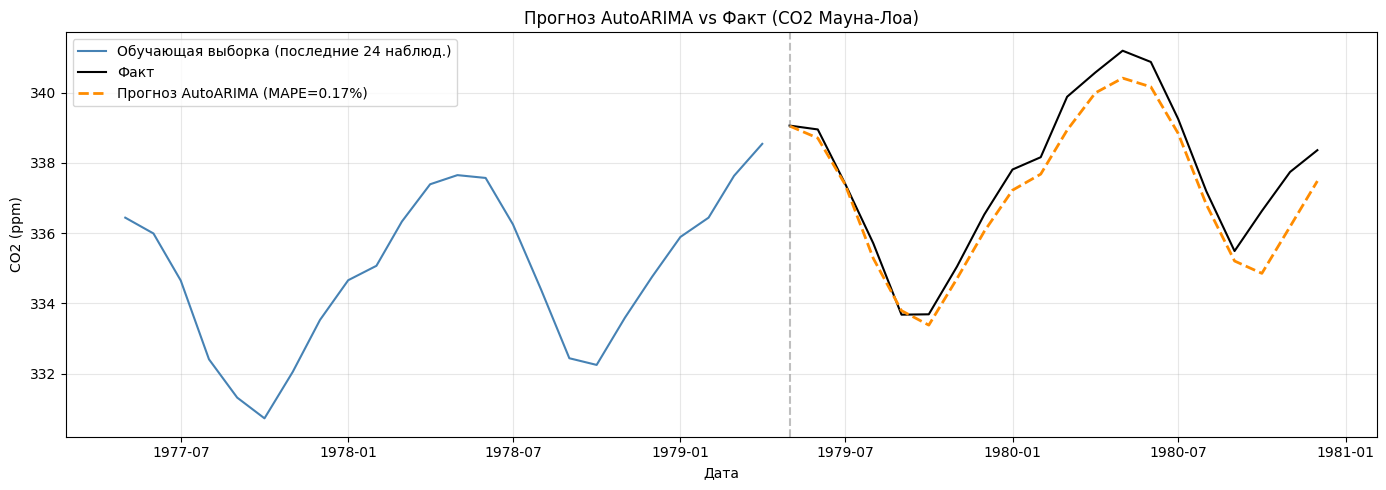


Сравнительная таблица:


,Модель,Порядок,Сезонный порядок,AIC,MAPE на тесте
0,Grid Search (лучший по AIC),"(0, 1, 1)","(0, 1, 1, 12)",90.5,0.19%
1,AutoARIMA,"(0, 1, 1)","(2, 1, 0, 12)",—,0.17%


In [ ]:

print("Запуск AutoARIMA (stepwise=True, trace=True):\n")
auto_model = pm.auto_arima(
    train['co2'],
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    m=12,
    seasonal=True,
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    d=None,
    D=1,
    test='adf',
    trace=True,
    stepwise=True,
    error_action='ignore',
    suppress_warnings=True
)

print("\n" + "=" * 60)
print(auto_model.summary())

# Прогноз AutoARIMA на тестовый период
auto_forecast = auto_model.predict(n_periods=len(test))
auto_forecast = pd.Series(auto_forecast, index=test.index)
auto_mape = float(np.abs((test['co2'].values - auto_forecast.values) / test['co2'].values).mean())

print(f"\nMAPE AutoARIMA на тесте: {auto_mape:.4f} ({auto_mape:.2%})")

# Параметры AutoARIMA
auto_ord  = auto_model.order
auto_sord = auto_model.seasonal_order

# Прогноз лучшей модели по AIC для сравнения в таблице
best_aic_mape = float(np.abs((test['co2'].values - preds[0].values) / test['co2'].values).mean()) \
    if len(preds) > 0 else None

# График AutoARIMA vs Факт
last_n = 24
train_tail = train['co2'].iloc[-last_n:]
plt.figure(figsize=(14, 5))
plt.plot(train_tail, label=f'Обучающая выборка (последние {last_n} наблюд.)', color='steelblue')
plt.plot(test['co2'], label='Факт', color='black', linewidth=1.5)
plt.plot(auto_forecast, label=f'Прогноз AutoARIMA (MAPE={auto_mape:.2%})',
         color='darkorange', linestyle='--', linewidth=2)
plt.axvline(test.index[0], color='gray', linestyle='--', alpha=0.5)
plt.title('Прогноз AutoARIMA vs Факт (CO2 Мауна-Лоа)')
plt.xlabel('Дата'); plt.ylabel('CO2 (ppm)')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Сравнительная таблица
best_aic_row2 = model_info.loc[model_info['AIC'].idxmin()]
compare_data = [
    ['Grid Search (лучший по AIC)', str(tuple(best_aic_row2['порядок'])),
     str(tuple(best_aic_row2['сезонный_порядок'])),
     f"{best_aic_row2['AIC']:.1f}",
     f"{mape_test_list[0]:.2%}" if mape_test_list else 'N/A'],
    ['AutoARIMA', str(auto_ord), str(auto_sord), '—', f"{auto_mape:.2%}"],
]
compare_df = pd.DataFrame(compare_data, columns=['Модель', 'Порядок', 'Сезонный порядок', 'AIC', 'MAPE на тесте'])
print("\nСравнительная таблица:")
display(compare_df)

AutoARIMA выбрал SARIMA(0,1,1)(2,1,0,12), несезонная часть совпала. а вот сезонная отличается вместо Q=1 взял P=2. результат при этом чуть лучше MAPE 0.17% против 0.19% у grid search
разница минимальная, оба варианта работают отлично. в нашем случае grid search дал более интерпретируемую модель с меньшим числом параметров

итог: для данного ряда обе модели показывают MAPE < 0.2%, что является отличным результатом. если нужна скорость, то AutoARIMA, если нужен полный контроль и понимание, то grid search